# Movie Recommendation System: Visualization & Interpretation

This notebook is the analyst's view of the movie recommendation system. We are not just checking numbers — we are explaining what they mean for users, for movie connections, and for recommendations.

We will walk through user behavior, network influence, and content similarity, then bring these three perspectives together.

This notebook focuses on understanding the results, not just generating them.

## 1. Data Loading & First Look

Here we load the main processed datasets used by the recommendation system.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style='whitegrid', palette='deep')
root = Path('..')
data_path = root / 'data' / 'processed'
outputs_path = root / 'outputs'

cleaned = pd.read_csv(data_path / 'cleaned_dataset.csv')
transactions = pd.read_csv(data_path / 'transactions.csv')
association_rules = pd.read_csv(data_path / 'association_rules.csv')
pagerank_scores = pd.read_csv(data_path / 'pagerank_scores.csv')
top_similar_movies = pd.read_csv(outputs_path / 'top_similar_movies.csv')

datasets = {
    'cleaned_dataset': cleaned,
    'transactions': transactions,
    'association_rules': association_rules,
    'pagerank_scores': pagerank_scores,
    'top_similar_movies': top_similar_movies,
}

for name, df in datasets.items():
    print(f'{name}: shape={df.shape}')
    print(f' columns={list(df.columns)}')
    print(df.head(2).to_string(index=False))
    print('-' * 80)

cleaned_dataset: shape=(101030, 14)
 columns=['userId', 'movieId', 'rating', 'timestamp', 'title_x', 'genres_x', 'title_clean', 'title_y', 'overview', 'genres_y', 'popularity', 'vote_average', 'runtime', 'release_date']
 userId  movieId  rating  timestamp                 title_x                                    genres_x      title_clean   title_y                                                                                                                                                                                                                                                                                                        overview                                                                                         genres_y  popularity  vote_average  runtime release_date
      1        1     4.0  964982703        toy story (1995) Adventure|Animation|Children|Comedy|Fantasy        toy story toy story Led by Woody, Andy's toys live happily in his room until Andy's birth

The dataset looks clean and structured, which means we can focus more on insights rather than fixing data issues. We have user-level behavior, association rules, graph influence scores, and semantic similarity scores ready for exploration.

## 2. Understanding the Dataset

Now we look at the shape of our recommendation data and what it tells us about the system.

Unique movies: 9445
Unique users: 610
Total interactions: 101030


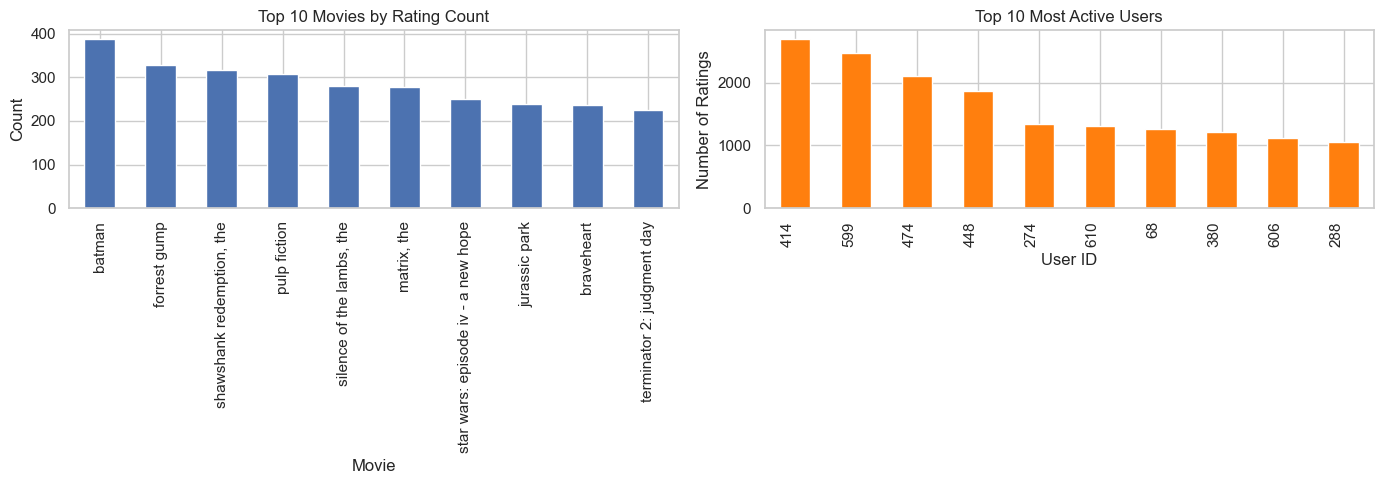

In [10]:
movie_counts = cleaned['title_clean'].value_counts().rename_axis('movie').reset_index(name='views')
user_counts = cleaned['userId'].value_counts().rename_axis('userId').reset_index(name='ratings_count')

print('Unique movies:', cleaned['title_clean'].nunique())
print('Unique users:', cleaned['userId'].nunique())
print('Total interactions:', len(cleaned))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
movie_counts.head(10).plot.bar(x='movie', y='views', ax=axes[0], legend=False)
axes[0].set_title('Top 10 Movies by Rating Count')
axes[0].set_xlabel('Movie')
axes[0].set_ylabel('Count')
plt.xticks(rotation=45, ha='right')

user_counts.head(10).plot.bar(x='userId', y='ratings_count', ax=axes[1], legend=False, color='tab:orange')
axes[1].set_title('Top 10 Most Active Users')
axes[1].set_xlabel('User ID')
axes[1].set_ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

We are working with a classic recommendation dataset: many users, many movies, and a broad distribution of interactions. This is exactly the kind of data where a hybrid recommendation approach makes sense.

## 3. Most Popular Movies (Behavior Perspective)

Popularity is a great starting point because it tells us what many users already like. But popularity is only one side of the story.

C:\Users\Arasc\AppData\Local\Temp\ipykernel_7844\1061920249.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_movies, y='movie', x='support', palette='crest')


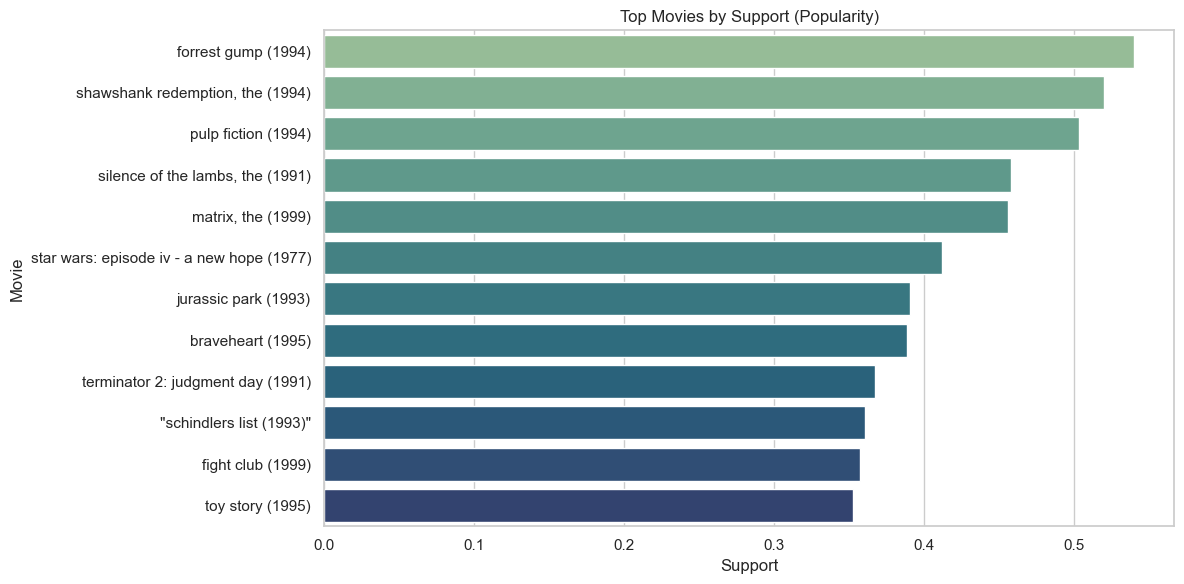

,movie,support
0,forrest gump (1994),0.539344
1,"shawshank redemption, the (1994)",0.519672
2,pulp fiction (1994),0.503279
3,"silence of the lambs, the (1991)",0.457377
4,"matrix, the (1999)",0.455738
5,star wars: episode iv - a new hope (1977),0.411475
6,jurassic park (1993),0.390164
7,braveheart (1995),0.388525
8,terminator 2: judgment day (1991),0.367213
9,"""schindlers list (1993)""",0.360656


In [14]:
frequent_itemsets = pd.read_csv(data_path / 'frequent_itemsets.csv')
single_movies = frequent_itemsets[frequent_itemsets['length'] == 1].copy()
single_movies['movie'] = (
    single_movies['itemsets']
    .astype(str)
    .str.strip('[]')
    .str.replace("'", "", regex=False)
    .str.strip()
)
top_movies = single_movies.sort_values('support', ascending=False).head(12)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_movies, y='movie', x='support', palette='crest')
plt.title('Top Movies by Support (Popularity)')
plt.xlabel('Support')
plt.ylabel('Movie')
plt.tight_layout()
plt.show()

top_movies[['movie', 'support']].reset_index(drop=True)

A movie is 
 when it appears in many user sessions. Popular movies are useful because they are safe recommendations, but they do not capture personal taste or surprise.

## 4. Association Rules Analysis (User Behavior)

Association rules reveal patterns in how users move from one movie to another. These are the real behavioral signals behind recommendations.

In [15]:
import ast

rules = association_rules.copy()
def format_itemset(cell):
    if isinstance(cell, str):
        try:
            items = ast.literal_eval(cell)
        except Exception:
            items = [cell]
    else:
        items = list(cell)
    return ', '.join(items)

rules['antecedent'] = rules['antecedents'].apply(format_itemset)
rules['consequent'] = rules['consequents'].apply(format_itemset)
rules['rule'] = rules['antecedent'] + ' → ' + rules['consequent']

top_rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False]).head(10)
top_rules[['rule', 'support', 'confidence', 'lift']].reset_index(drop=True)

,rule,support,confidence,lift
0,"matrix, the (1999), lord of the rings: the ret...",0.213115,0.878378,3.227776
1,"lord of the rings: the fellowship of the ring,...",0.213115,0.783133,3.227776
2,"lord of the rings: the two towers, the (2002),...",0.213115,0.872483,3.225544
3,"lord of the rings: the fellowship of the ring,...",0.213115,0.787879,3.225544
4,"lord of the rings: the fellowship of the ring,...",0.213115,0.962963,3.175175
5,"lord of the rings: the return of the king, the...",0.213115,0.702703,3.175175
6,"lord of the rings: the fellowship of the ring,...",0.213115,0.828025,3.137239
7,"lord of the rings: the two towers, the (2002),...",0.213115,0.807453,3.137239
8,star wars: episode vi - return of the jedi (19...,0.200000,0.960630,3.084128
9,star wars: episode v - the empire strikes back...,0.200000,0.642105,3.084128


These rules summarize behavior like: if a user watched one group of movies, they are likely to watch another group next. That is stronger than just saying a movie is popular.

### What the rule metrics mean

* **Support** measures how often the full rule appears in the data.
* **Confidence** measures how often the consequent is seen when the antecedent appears.
* **Lift** measures how much the rule improves over random chance. A lift above 1 means the rule is stronger than a random association.

These rules show that users tend to follow patterns, not random choices. A strong rule is evidence that one movie choice often leads to another.

## 5. Visualizing Rules

Now we use the pre-generated rule charts to see the distribution and the strongest recommendations.

### Confidence distribution

![Confidence Distribution](../outputs/charts/confidence_distribution.png)

The confidence distribution shows how many rules are moderately strong versus highly certain. It helps identify whether we have a few reliable rules or many weak ones.

### Confidence vs Lift

![Confidence vs Lift](../outputs/charts/confidence_vs_lift.png)

We can clearly see that only a small portion of rules have both high confidence and high lift — these are the most valuable recommendations. The best rules are not just frequent, they are also surprising and strong.

### Top 10 rules by lift

![Top 10 Rules by Lift](../outputs/charts/top10_rules_lift.png)

This chart focuses on the highest-return rules. These are the associations that carry the most predictive power in the user behavior model.

## 6. Graph-Based Analysis (Movie Network)

Graph analysis helps us understand movie influence beyond individual popularity. A strong movie in the network can connect many others, even if it is not the top watch count.

C:\Users\Arasc\AppData\Local\Temp\ipykernel_7844\2571533061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pagerank, y='movie', x='pagerank', palette='mako')


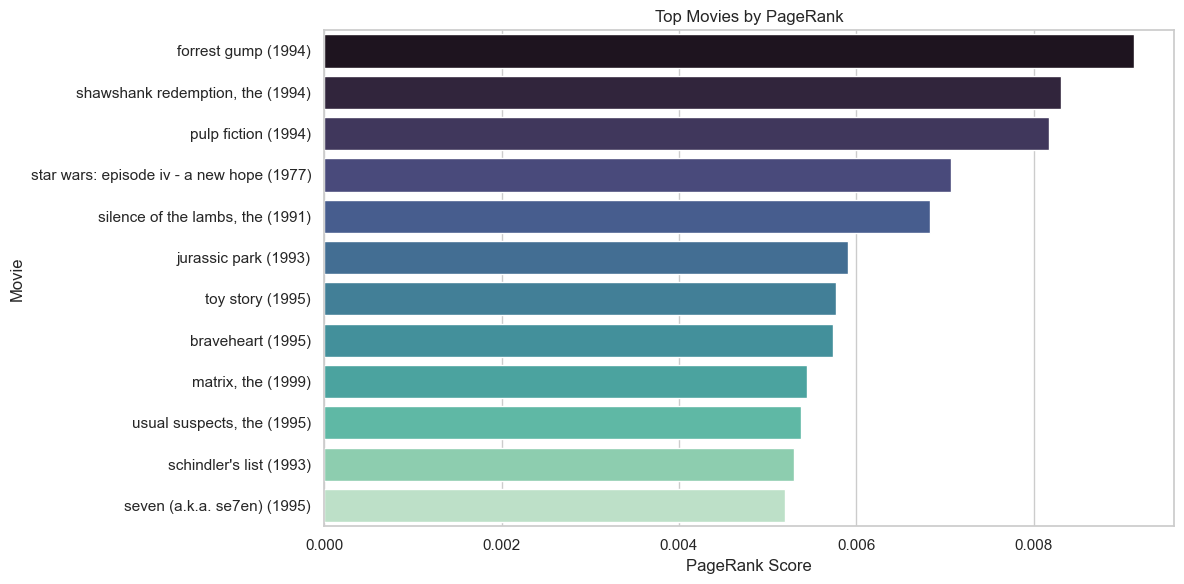

,movie,pagerank
0,forrest gump (1994),0.009127
1,"shawshank redemption, the (1994)",0.008310
2,pulp fiction (1994),0.008179
3,star wars: episode iv - a new hope (1977),0.007070
4,"silence of the lambs, the (1991)",0.006830
5,jurassic park (1993),0.005901
6,toy story (1995),0.005766
7,braveheart (1995),0.005740
8,"matrix, the (1999)",0.005446
9,"usual suspects, the (1995)",0.005374


In [16]:
graph_data = pd.read_csv(data_path / 'graph_data.csv')
top_pagerank = pagerank_scores.sort_values('pagerank', ascending=False).head(12)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_pagerank, y='movie', x='pagerank', palette='mako')
plt.title('Top Movies by PageRank')
plt.xlabel('PageRank Score')
plt.ylabel('Movie')
plt.tight_layout()
plt.show()

top_pagerank[['movie', 'pagerank']].reset_index(drop=True)

PageRank measures movie influence inside the network of co-watch relationships. A high PageRank movie appears in many strong connections and helps bridge groups of movies.

A movie can be influential even if it's not the most watched. It may be a central connector between genres or fan communities.

## 7. Comparing Popularity vs Influence

This section contrasts the movies users watch most often with the movies that shape connections across the network.

In [18]:
popular = single_movies.sort_values('support', ascending=False).head(8).copy()
popular['movie'] = popular['movie'].str.strip()
influential = top_pagerank.copy()
influential = influential.head(len(popular)).copy()

comparison = pd.DataFrame({
    'Popular Movie': popular['movie'].values,
    'Support': popular['support'].values,
    'Influential Movie': influential['movie'].values,
    'PageRank': influential['pagerank'].values,
})
comparison

,Popular Movie,Support,Influential Movie,PageRank
0,forrest gump (1994),0.539344,forrest gump (1994),0.009127
1,"shawshank redemption, the (1994)",0.519672,"shawshank redemption, the (1994)",0.008310
2,pulp fiction (1994),0.503279,pulp fiction (1994),0.008179
3,"silence of the lambs, the (1991)",0.457377,star wars: episode iv - a new hope (1977),0.007070
4,"matrix, the (1999)",0.455738,"silence of the lambs, the (1991)",0.006830
5,star wars: episode iv - a new hope (1977),0.411475,jurassic park (1993),0.005901
6,jurassic park (1993),0.390164,toy story (1995),0.005766
7,braveheart (1995),0.388525,braveheart (1995),0.005740


Popular movies are frequently watched by many users. Influential movies connect different parts of the network and may be the best way to steer recommendations between clusters.

## 8. Content-Based Similarity (NLP)

Here we inspect semantic similarity results, which capture what movies are about rather than just what users watched.

In [19]:
example_movie = 'Avatar'
similar_examples = top_similar_movies[top_similar_movies['movie_title'] == example_movie].sort_values('rank').head(5)
similar_examples.reset_index(drop=True)

,movie_title,similar_movie_title,similarity_score,rank
0,Avatar,Alien: Resurrection,0.475206,1
1,Avatar,Aliens,0.453270,2
2,Avatar,The Black Hole,0.443850,3
3,Avatar,Serenity,0.426232,4
4,Avatar,Sphere,0.420612,5


The similarity score is based on movie content embeddings, which capture plot, themes, and meaning. This helps recommend titles even when user behavior is sparse.

These content-based recommendations are especially valuable for cold-start movies or users who have not watched many titles yet.

## 9. Combining All Perspectives

At this point, it becomes clear that no single method is enough. Each approach answers a different question.

* Behavior (Pattern Mining) answers: What do users watch together?
* Network (Graph) answers: What movies connect clusters and act as bridges?
* Meaning (BERT) answers: What movies are actually similar in content?

A strong recommendation system uses all three. Popularity helps with general demand, association rules capture real user journeys, PageRank finds connective movies, and NLP brings in meaning.

## 10. Key Insights

* Users follow clear viewing patterns — strong rules show repeated movie sequences.
* High lift rules reveal relationships that are much stronger than random chance.
* Popular movies are not always the same as the most influential movies in the network.
* Graph analysis highlights hidden connectors that can improve recommendation reach.
* NLP similarity captures meaning and supports recommendations when behavior data is weak.
* A hybrid approach is more reliable than popularity alone.
* The combination of behavior, influence, and content gives a fuller view of what users want.

## 11. Conclusion

This analysis shows that the movie recommendation system benefits from multiple perspectives. We learned that users do not choose movies at random — there are patterns, influence structures, and semantic similarities at play.

These findings matter because they help us build recommendations that feel relevant, connected, and meaningful instead of just popular.

This project is not just about recommending movies — it's about understanding why those recommendations make sense.